# Impact of AI on Students — Data

Cleaning & Exploratory Analysis

**Dataset:** AI Student Impact Dataset (50,000 student records)
**Goal:** Clean the dataset, explore patterns in how Generative AI tool usage relates to academic performance, study habits, and well-being, and visualize key findings.

## Dataset Overview
The dataset captures Generative AI tool usage and its relationship to academic outcomes, behavior, institutional context, and psychological well-being for 50,000 students. Columns include:



## **Step** 1: **Load** **the** **Dataset** **and** **Inspect** **Structure**

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/ai_student_impact_dataset (1).csv')
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [ ]:
df.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level', 'Hours_Bucket'],
      dtype='object')

In [ ]:
df.shape

(50000, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

## **Step** **2**: **Data** **Cleaning**

We check for missing values, duplicate rows, and incorrect data types before doing any analysis.

In [ ]:
df.isnull().sum()

,0
Student_ID,0
Major_Category,0
Year_of_Study,0
Pre_Semester_GPA,0
Weekly_GenAI_Hours,0
Primary_Use_Case,0
Prompt_Engineering_Skill,0
Tool_Diversity,0
Paid_Subscription,0
Traditional_Study_Hours,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Student_IDs:", df['Student_ID'].duplicated().sum())


Duplicate rows: 0
Duplicate Student_IDs: 0


In [ ]:
df.dtypes

,0
Student_ID,int64
Major_Category,object
Year_of_Study,object
Pre_Semester_GPA,float64
Weekly_GenAI_Hours,float64
Primary_Use_Case,object
Prompt_Engineering_Skill,object
Tool_Diversity,int64
Paid_Subscription,bool
Traditional_Study_Hours,float64


In [ ]:

for col in numeric_cols:

 df[col] = df[col].fillna(df[col].median())


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
  df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
Student_ID,0
Major_Category,0
Year_of_Study,0
Pre_Semester_GPA,0
Weekly_GenAI_Hours,0
Primary_Use_Case,0
Prompt_Engineering_Skill,0
Tool_Diversity,0
Paid_Subscription,0
Traditional_Study_Hours,0


In [ ]:
df.to_csv('cleaned_dataset.csv',index=False)

## **Step** **3**: **Exploratory** **Data** **Analysis** (EDA)

We calculate summary statistics and look for correlations and trends in the data.


In [ ]:

df.groupby('Burnout_Risk_Level')['Anxiety_Level_During_Exams'].mean().sort_values(ascending=False)


,Anxiety_Level_During_Exams
Burnout_Risk_Level,
High,4.889325
Medium,4.170450
Low,3.928462


In [ ]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [ ]:
df.describe(include='object')

,Major_Category,Year_of_Study,Primary_Use_Case,Prompt_Engineering_Skill,Institutional_Policy,Burnout_Risk_Level
count,50000,50000,50000,50000,50000,50000
unique,5,5,5,3,3,3
top,STEM,Junior,Debugging/Troubleshooting,Beginner,Allowed_With_Citation,Medium
freq,15059,11045,12295,18495,25224,21144


In [ ]:

for col in ['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Institutional_Policy', 'Burnout_Risk_Level']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


--- Major_Category ---
Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

--- Year_of_Study ---
Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64

--- Primary_Use_Case ---
Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64

--- Institutional_Policy ---
Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64

--- Burnout_Risk_Level ---
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64



## **Step** **4**: **Visualizations**

At least three distinct visualizations to represent the findings above: a histogram, a scatter plot, and a correlation heatmap.




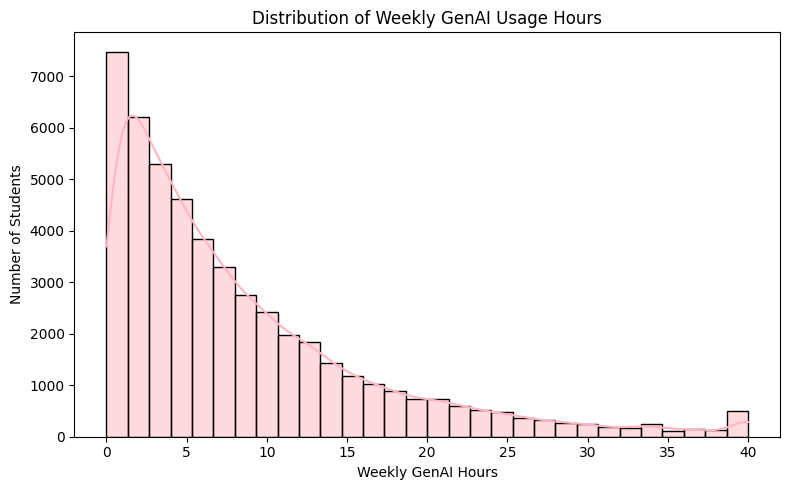

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.histplot(df['Weekly_GenAI_Hours'], bins=30, kde=True, color='lightpink')
plt.title('Distribution of Weekly GenAI Usage Hours')
plt.xlabel('Weekly GenAI Hours')
plt.ylabel('Number of Students')
plt.savefig('weekly_genai_hours_distribution.png')
plt.tight_layout()
plt.show()


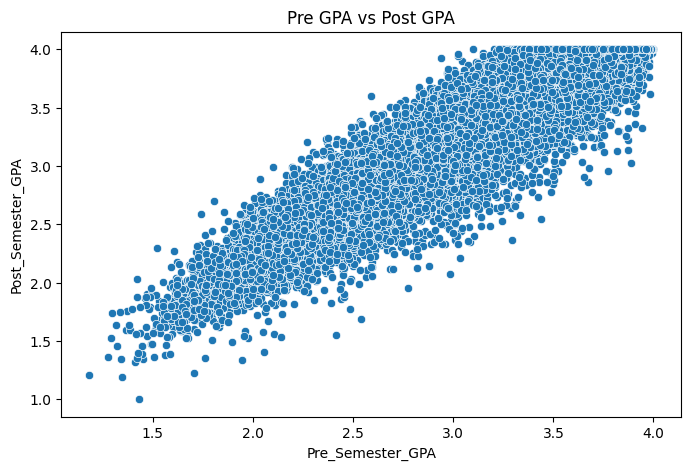

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Pre_Semester_GPA',
    y='Post_Semester_GPA'
)
plt.title('Pre GPA vs Post GPA')
plt.savefig('gpa_comparision.png')
plt.show()

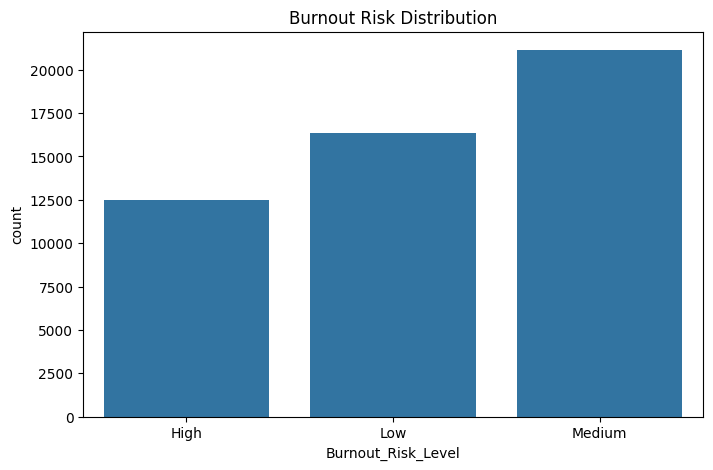

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='Burnout_Risk_Level',
)
plt.title('Burnout Risk Distribution')
plt.savefig('burnout_risk_level.png')
plt.show()


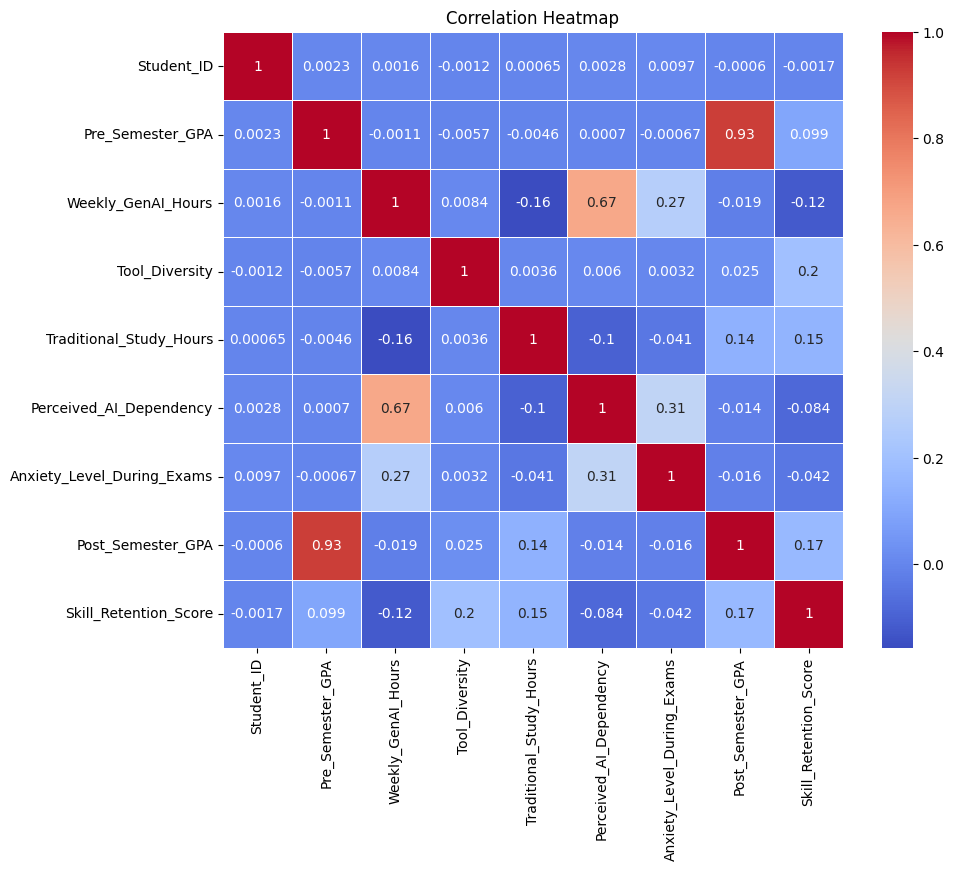

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()

 **KEY INSIGHTS**
 -Students from different majors use AI tools at different rates.
 -Higher AI usage may be associated with changes in GPA.
 -Some students report higher AI dependency
 -Burnout levels vary across the student population
 -Skill retention can be analyzed against AI usage